In [2]:
!pip install -q --upgrade keras-cv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 58.9 MB/s eta 0:00:00


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step

-- (Record Data) ---

 picture 1:
 classification dog |score: 0.95

 picture 2:
 classification car |score: 0.97

 picture 3:

 picture 4:

 picture 5:
 classification bird |score: 0.60


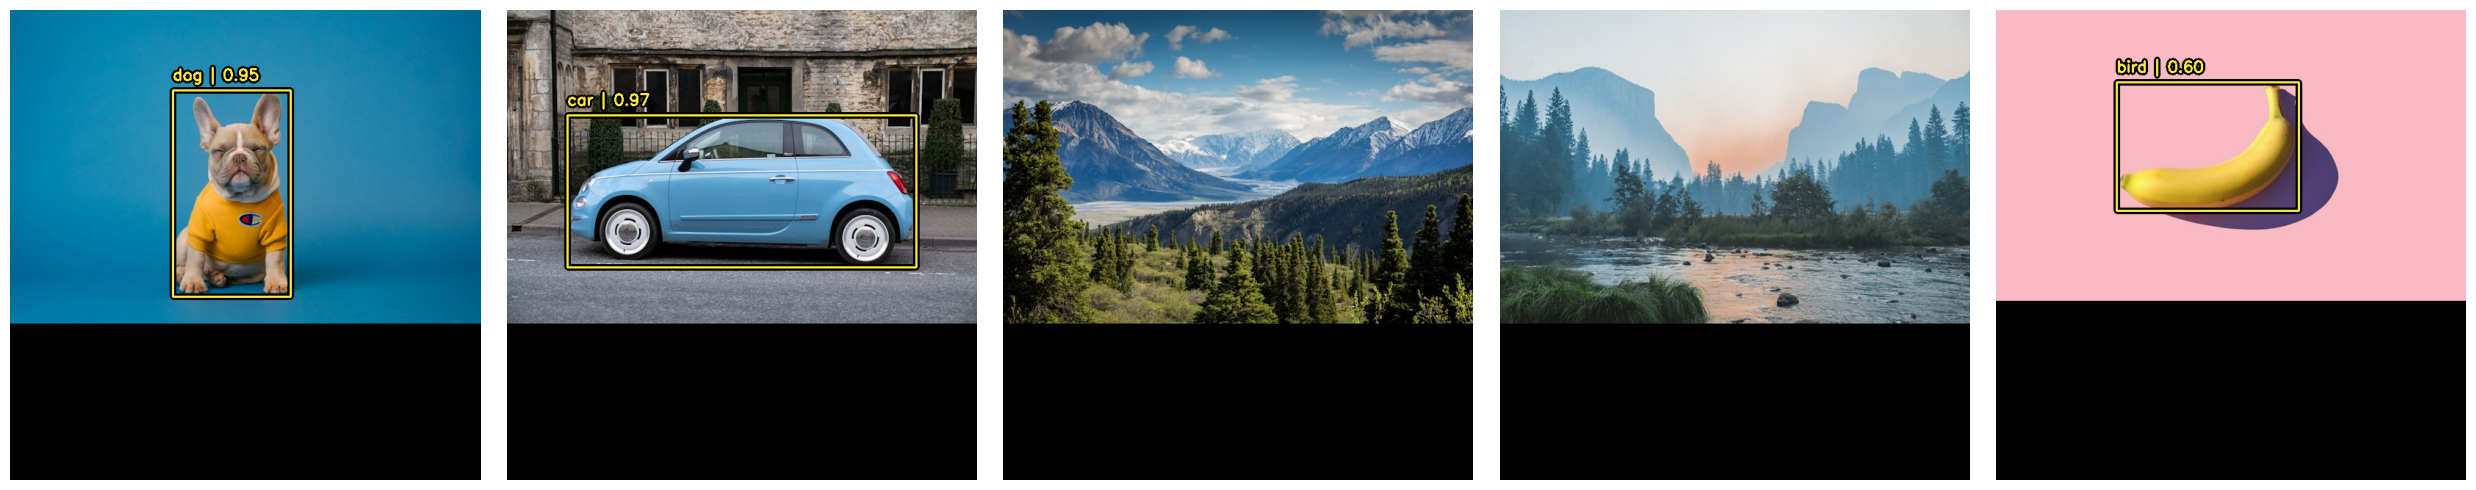

In [19]:
import keras_cv
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

image_urls = [
    "https://images.unsplash.com/photo-1583511655857-d19b40a7a54e?q=80&w=640", # Dog
    "https://images.unsplash.com/photo-1549317661-bd32c8ce0db2?q=80&w=640", # Chair/Sofa
    "https://images.unsplash.com/photo-1464822759023-fed622ff2c3b?q=80&w=640", # Horse/Mountain
    "https://images.unsplash.com/photo-1506744038136-46273834b3fb?q=80&w=640", # Person/Boat
    "https://images.unsplash.com/photo-1481349518771-20055b2a7b24?q=80&w=640"  # Banana (VOC category: Bottle/Diningtable context)
]

inference_resizing = keras_cv.layers.Resizing(640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh")

def load_and_prep(url, i):
    path = tf.keras.utils.get_file(f"final_test_{i}.jpg", origin=url)
    img = tf.image.decode_jpeg(tf.io.read_file(path), channels=3)
    return inference_resizing(img)

images = tf.stack([load_and_prep(u, i) for i, u in enumerate(image_urls)])

predictions = model.predict(images)

class_ids = ["aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car", "cat",
             "chair", "cow", "diningtable", "dog", "horse", "motorbike", "person",
             "pottedplant", "sheep", "sofa", "train", "tvmonitor"]
class_mapping = dict(zip(range(len(class_ids)), class_ids))

print("\n-- (Record Data) ---")
for i in range(len(image_urls)):
    boxes = predictions['boxes'][i]
    classes = predictions['classes'][i]
    confidence = predictions['confidence'][i]

    mask = confidence > 0.4
    print(f"\n picture {i+1}:")
    for cls_id, conf in zip(classes[mask], confidence[mask]):
        print(f" classification {class_mapping[int(cls_id)]} |score: {conf:.2f}")

keras_cv.visualization.plot_bounding_box_gallery(
    images, value_range=(0, 255), y_pred=predictions,
    rows=1, cols=5, scale=5, font_scale=0.7,
    bounding_box_format="xywh", class_mapping=class_mapping,
)
plt.show()